# Python Extension of DESeq2 Results: Filtering, Annotation Mining, and Visualization of Differentially Expressed Genes

**Author:** Liz Dauster  
**Date:** May 8, 2026  
**Dataset:** GEO accession GSE203539  
**Primary upstream workflow:** Galaxy RNA-seq preprocessing and R/DESeq2 differential expression analysis

## Project purpose

This notebook extends an R-based DESeq2 workflow using Python to clean, combine, filter, summarize, visualize, and text-mine annotated DESeq2 result tables across cell types and treatment contrasts.

This project focuses on practical scientific data analysis: taking output from one bioinformatics toolchain and turning it into interpretable, reusable, cross-contrast summaries and reporting tables.


## Project question

How can Python be used as a reproducible reporting layer for annotated DESeq2 results?

This notebook imports DESeq2 outputs from an upstream R workflow, standardizes results across contrasts, filters high-confidence DEGs, summarizes response patterns, and uses lightweight annotation text mining to identify recurring biological themes.

## Data inputs

This notebook expects annotated DESeq2 result tables generated from the upstream R script. Place these files in a local `data/` folder:

- `AEC_WSN_vs_mock_DESeq2_annot.txt`
- `AEC_WSNPP1_vs_WSN_DESeq2_annot.txt`
- `AM_WSN_vs_mock_DESeq2_annot.txt`
- `AM_WSNPP1_vs_WSN_DESeq2_annot.txt`

Each file should contain DESeq2 results merged with gene annotation fields, including at minimum:

- gene identifier
- log2 fold change
- adjusted p-value
- gene symbol or gene name, if available
- annotation text fields, if available

The notebook is written defensively so that column names can vary slightly across annotation files.  
**Annotation source:** Ensembl Mus musculus GRCm39 gene annotation (`GRCm39_annotation.txt`)


In [1]:
# Core libraries
from pathlib import Path
from collections import Counter
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Notebook display settings
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Input/output folders
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Filtering threshold used for high-confidence DEGs
PADJ_THRESHOLD = 0.005
LOG2FC_THRESHOLD = 2

print("Ready.")
print(f"Using thresholds: padj < {PADJ_THRESHOLD}, abs(log2FoldChange) > {LOG2FC_THRESHOLD}")

Ready.
Using thresholds: padj < 0.005, abs(log2FoldChange) > 2


## Load annotated DESeq2 result tables

Each DESeq2 result file is loaded with metadata identifying its cell type and treatment contrast.

In [2]:
# File registry for the four planned contrasts
contrast_files = [{"cell_type": "AEC",
                   "contrast": "WSN vs mock",
                   "file": DATA_DIR / "AEC_WSN_vs_mock_DESeq2_annot.txt"},
                  
                  {"cell_type": "AEC",
                   "contrast": "WSN_PP1 vs WSN",
                   "file": DATA_DIR / "AEC_WSNPP1_vs_WSN_DESeq2_annot.txt"},
                  
                  {"cell_type": "AM",
                   "contrast": "WSN vs mock",
                   "file": DATA_DIR / "AM_WSN_vs_mock_DESeq2_annot.txt"},
                  
                  {"cell_type": "AM",
                   "contrast": "WSN_PP1 vs WSN",
                   "file": DATA_DIR / "AM_WSNPP1_vs_WSN_DESeq2_annot.txt"}]

def load_contrast_table(record):
    """Load one annotated DESeq2 result table and add metadata columns."""
    path = record["file"]

    # Fail early if an expected input file is missing
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}\n"
                                "Check that the DESeq2 annotated result tables are saved in the data/ folder."
                               )

    # Read DESeq2 output and preserve its experimental context
    df = pd.read_csv(path, sep="\t")
    df["cell_type"] = record["cell_type"]
    df["contrast"] = record["contrast"]
    df["source_file"] = path.name
    return df

# Load all contrast tables and combine them into one analysis dataset
tables = [load_contrast_table(record) for record in contrast_files]
deg_raw = pd.concat(tables, ignore_index=True)

# Quick shape check before downstream cleaning
print(f"Combined rows: {deg_raw.shape[0]:,}")
print(f"Combined columns: {deg_raw.shape[1]:,}")

deg_raw.head()

Combined rows: 94,540
Combined columns: 18


,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Gene.stable.ID.version,Gene.name,Gene.type,Gene.end..bp.,Gene.description,Gene.start..bp.,Transcript.stable.ID,Transcript.stable.ID.version,cell_type,contrast,source_file
0,ENSMUSG00000014599,7565.851831,1.507941,0.039683,37.999362,0.0,0.0,ENSMUSG00000014599.11,Csf1,protein_coding,107667785,colony stimulating factor 1 (macrophage) [Source:MGI Symbol;Acc:MGI:1339753],107648364,ENSMUST00000118593,ENSMUST00000118593.8,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt
1,ENSMUSG00000025492,1518.995110,2.930411,0.074697,39.230622,0.0,0.0,ENSMUSG00000025492.7,Ifitm3,protein_coding,140590683,interferon induced transmembrane protein 3 [Source:MGI Symbol;Acc:MGI:1913391],140589499,ENSMUST00000026565,ENSMUST00000026565.7,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt
2,ENSMUSG00000025498,974.893703,6.389677,0.167266,38.200776,0.0,0.0,ENSMUSG00000025498.16,Irf7,protein_coding,140846394,interferon regulatory factor 7 [Source:MGI Symbol;Acc:MGI:1859212],140842619,ENSMUST00000106023,ENSMUST00000106023.8,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt
3,ENSMUSG00000027962,2478.732487,3.790283,0.067517,56.137830,0.0,0.0,ENSMUSG00000027962.15,Vcam1,protein_coding,115923337,vascular cell adhesion molecule 1 [Source:MGI Symbol;Acc:MGI:98926],115903598,ENSMUST00000029574,ENSMUST00000029574.13,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt
4,ENSMUSG00000028270,2413.071612,7.039520,0.133088,52.893669,0.0,0.0,ENSMUSG00000028270.13,Gbp2,protein_coding,142343769,guanylate binding protein 2 [Source:MGI Symbol;Acc:MGI:102772],142326363,ENSMUST00000165774,ENSMUST00000165774.8,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt


## Standardize and clean DEG result tables

DESeq2 and annotation outputs can use different column names depending on the export source. This section identifies common DEG and annotation fields, standardizes them into a consistent analysis table, and removes rows that cannot be evaluated for differential expression.

The standardized table includes:

- gene IDs and gene symbols
- log2 fold changes
- adjusted p-values
- annotation descriptions and biotypes
- experimental metadata including cell type and contrast

Rows with missing adjusted p-values or log2 fold changes are removed prior to downstream DEG filtering and visualization.

In [3]:
def find_first_existing_column(df, candidates):
    """Return the first column name present in df from a list of candidates."""
    for col in candidates:
        if col in df.columns:
            return col
    return None


# Identify key columns, allowing for common DESeq2 / BioMart naming differences
gene_id_col = find_first_existing_column(deg_raw, ["GeneID",
                                                   "Gene.stable.ID",
                                                   "Gene.stable.ID.version"])

symbol_col = find_first_existing_column(deg_raw, ["Gene.name"])

description_col = find_first_existing_column(deg_raw, ["Gene.description"])

biotype_col = find_first_existing_column(deg_raw, ["Gene.type"])

gene_start_col = find_first_existing_column(deg_raw, ["Gene.start..bp."])

gene_end_col = find_first_existing_column(deg_raw, ["Gene.end..bp."])

transcript_id_col = find_first_existing_column(deg_raw, ["Transcript.stable.ID",
                                                         "Transcript.stable.ID.version"])

# Define columns required for DEG filtering and ranking
required = {"gene_id_col": gene_id_col,
            "log2FoldChange": "log2FoldChange" if "log2FoldChange" in deg_raw.columns else None,
            "padj": "padj" if "padj" in deg_raw.columns else None}

# Print detected columns for reproducibility and troubleshooting
print("Detected columns:")
print("gene_id:", gene_id_col)
print("symbol:", symbol_col)
print("description:", description_col)
print("biotype:", biotype_col)
print("log2FoldChange:", required["log2FoldChange"])
print("padj:", required["padj"])

# Stop the notebook early if required columns are missing
missing_required = [name for name, value in required.items() if value is None]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Build standardized analysis table
deg = pd.DataFrame({"gene_id": deg_raw[gene_id_col].astype(str),
                    "gene_symbol": deg_raw[symbol_col].astype(str) if symbol_col else deg_raw[gene_id_col].astype(str),
                    "log2FoldChange": pd.to_numeric(deg_raw["log2FoldChange"], errors="coerce"),
                    "padj_raw": deg_raw["padj"].astype(str),
                    "padj": pd.to_numeric(deg_raw["padj"], errors="coerce"),
                    "cell_type": deg_raw["cell_type"],
                    "contrast": deg_raw["contrast"],
                    "source_file": deg_raw["source_file"]})

# Add optional annotation fields when available
deg["description"] = deg_raw[description_col].astype(str) if description_col else ""
deg["biotype"] = deg_raw[biotype_col].astype(str) if biotype_col else "unknown"

# Convert placeholder text values into true missing values
for col in ["gene_symbol", "description", "biotype"]:
    deg[col] = (deg[col].replace({"nan": np.nan, "None": np.nan, "": np.nan}))

# Use gene ID as a fallback label when a gene symbol is unavailable
deg["gene_label"] = deg["gene_symbol"].fillna(deg["gene_id"])

# Remove rows that cannot be evaluated for statistical significance
before = len(deg)
deg = deg.dropna(subset=["padj", "log2FoldChange"]).copy()
after = len(deg)

print(f"Rows removed due to missing padj/log2FoldChange: {before - after:,}")
print(f"Rows retained: {after:,}")

deg.head()

Detected columns:
gene_id: GeneID
symbol: Gene.name
description: Gene.description
biotype: Gene.type
log2FoldChange: log2FoldChange
padj: padj
Rows removed due to missing padj/log2FoldChange: 15,687
Rows retained: 78,853


,gene_id,gene_symbol,log2FoldChange,padj_raw,padj,cell_type,contrast,source_file,description,biotype,gene_label
0,ENSMUSG00000014599,Csf1,1.507941,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,colony stimulating factor 1 (macrophage) [Source:MGI Symbol;Acc:MGI:1339753],protein_coding,Csf1
1,ENSMUSG00000025492,Ifitm3,2.930411,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,interferon induced transmembrane protein 3 [Source:MGI Symbol;Acc:MGI:1913391],protein_coding,Ifitm3
2,ENSMUSG00000025498,Irf7,6.389677,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,interferon regulatory factor 7 [Source:MGI Symbol;Acc:MGI:1859212],protein_coding,Irf7
3,ENSMUSG00000027962,Vcam1,3.790283,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,vascular cell adhesion molecule 1 [Source:MGI Symbol;Acc:MGI:98926],protein_coding,Vcam1
4,ENSMUSG00000028270,Gbp2,7.039520,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,guanylate binding protein 2 [Source:MGI Symbol;Acc:MGI:102772],protein_coding,Gbp2


## Add genomic metadata from BioMart

Additional gene-level metadata was downloaded from Ensembl BioMart and joined to the DESeq2 results using Ensembl gene stable IDs. This adds chromosome, strand, transcript count, and GC content for downstream summaries and visualization.

In [4]:
biomart_path = DATA_DIR / "biomart_mouse_gene_metadata.txt"

biomart = pd.read_csv(biomart_path, sep="\t")

biomart = biomart.rename(columns={"Gene stable ID": "gene_id",
                                  "Chromosome/scaffold name": "chromosome",
                                  "Strand": "strand",
                                  "Transcript count": "transcript_count",
                                  "Gene % GC content": "gene_gc_content"})

# Keep one row per gene ID
biomart = biomart.drop_duplicates(subset="gene_id")

# Join BioMart metadata onto DESeq2 results
before_cols = deg.shape[1]

deg = deg.merge(biomart, on="gene_id", how="left")

after_cols = deg.shape[1]

print(f"BioMart rows: {len(biomart):,}")
print(f"Columns added: {after_cols - before_cols}")
print(f"Rows after join: {len(deg):,}")
print(f"Genes with chromosome metadata: {deg['chromosome'].notna().sum():,}")

deg.head()

BioMart rows: 78,334
Columns added: 4
Rows after join: 78,853
Genes with chromosome metadata: 78,853


,gene_id,gene_symbol,log2FoldChange,padj_raw,padj,cell_type,contrast,source_file,description,biotype,gene_label,chromosome,transcript_count,gene_gc_content,strand
0,ENSMUSG00000014599,Csf1,1.507941,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,colony stimulating factor 1 (macrophage) [Source:MGI Symbol;Acc:MGI:1339753],protein_coding,Csf1,3,7,51.22,-1
1,ENSMUSG00000025492,Ifitm3,2.930411,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,interferon induced transmembrane protein 3 [Source:MGI Symbol;Acc:MGI:1913391],protein_coding,Ifitm3,7,1,51.14,-1
2,ENSMUSG00000025498,Irf7,6.389677,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,interferon regulatory factor 7 [Source:MGI Symbol;Acc:MGI:1859212],protein_coding,Irf7,7,13,54.82,-1
3,ENSMUSG00000027962,Vcam1,3.790283,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,vascular cell adhesion molecule 1 [Source:MGI Symbol;Acc:MGI:98926],protein_coding,Vcam1,3,4,39.91,-1
4,ENSMUSG00000028270,Gbp2,7.039520,0.0,0.0,AEC,WSN vs mock,AEC_WSN_vs_mock_DESeq2_annot.txt,guanylate binding protein 2 [Source:MGI Symbol;Acc:MGI:102772],protein_coding,Gbp2,3,2,40.92,1


## Classify high-confidence differentially expressed genes

Genes are classified as:

- **Upregulated:** `padj < 0.005` and `log2FoldChange > 2`
- **Downregulated:** `padj < 0.005` and `log2FoldChange < -2`
- **Not high-confidence:** all other genes

This creates a simple, reproducible rule for comparing results across cell types and contrasts.


In [5]:
def classify_deg(row):
    """Classify genes using adjusted p-value and log2 fold-change thresholds."""
    if row["padj"] < PADJ_THRESHOLD and row["log2FoldChange"] > LOG2FC_THRESHOLD:
        return "Upregulated"
    if row["padj"] < PADJ_THRESHOLD and row["log2FoldChange"] < -LOG2FC_THRESHOLD:
        return "Downregulated"
    return "Not high-confidence"


# Apply DEG classification to each row
deg["regulation"] = deg.apply(classify_deg, axis=1)

# Create a Boolean flag for easier filtering downstream
deg["is_high_confidence_deg"] = deg["regulation"].isin(["Upregulated", "Downregulated"])

# Map technical contrast names to plain-language biological questions
contrast_label_map = {("AEC", "WSN vs mock"): "Infection response",
                      ("AEC", "WSN_PP1 vs WSN"): "Inhibitor effect",
                      ("AM", "WSN vs mock"): "Infection response",
                      ("AM", "WSN_PP1 vs WSN"): "Inhibitor effect"}

# Add biological context while preserving the original contrast label
deg["biological_question"] = deg.apply(lambda row: contrast_label_map.get((row["cell_type"], row["contrast"]), row["contrast"]), axis=1)

# Keep only high-confidence DEGs for downstream summaries and plots
high_conf = deg[deg["is_high_confidence_deg"]].copy()

print(f"High-confidence DEGs: {len(high_conf):,}")

high_conf[["cell_type", "biological_question", "contrast", "gene_label", "log2FoldChange", "padj_raw", "regulation"]].head(10)

High-confidence DEGs: 3,575


,cell_type,biological_question,contrast,gene_label,log2FoldChange,padj_raw,regulation
1,AEC,Infection response,WSN vs mock,Ifitm3,2.930411,0.0,Upregulated
2,AEC,Infection response,WSN vs mock,Irf7,6.389677,0.0,Upregulated
3,AEC,Infection response,WSN vs mock,Vcam1,3.790283,0.0,Upregulated
4,AEC,Infection response,WSN vs mock,Gbp2,7.039520,0.0,Upregulated
5,AEC,Infection response,WSN vs mock,Oasl2,5.881289,0.0,Upregulated
6,AEC,Infection response,WSN vs mock,Usp18,5.101842,0.0,Upregulated
7,AEC,Infection response,WSN vs mock,Lgals3bp,3.958363,0.0,Upregulated
8,AEC,Infection response,WSN vs mock,Art3,6.316955,0.0,Upregulated
9,AEC,Infection response,WSN vs mock,Cxcl10,5.822679,0.0,Upregulated
10,AEC,Infection response,WSN vs mock,Ccl7,4.831469,0.0,Upregulated


**Note:** Some adjusted p-values were smaller than Python’s floating-point precision range and appeared as `0.0` after numeric conversion. The original adjusted p-value text was retained as `padj_raw` for reporting, while numeric `padj` was used for threshold filtering.

## DEG count summaries

This section aggregates high-confidence DEG counts across contrasts.

These tables are useful for quickly comparing the magnitude and direction of transcriptional response between:

- AEC vs AM cell types
- infection response contrasts
- inhibitor effect contrasts


In [6]:
# Count genes by cell type, biological question, contrast, and DEG classification
summary_counts = (deg.groupby(["cell_type", "biological_question", "contrast", "regulation"]).size().reset_index(name="gene_count"))

# Reshape counts so each regulation category becomes its own column
summary_pivot = (summary_counts.pivot_table(index=["cell_type", "biological_question", "contrast"],
                                            columns="regulation",
                                            values="gene_count",
                                            fill_value=0).reset_index())

# Ensure expected columns exist even if no genes fall into a category
for col in ["Upregulated", "Downregulated", "Not high-confidence"]:
    if col not in summary_pivot.columns:
        summary_pivot[col] = 0

# Total high-confidence DEGs are the upregulated and downregulated genes
summary_pivot["High-confidence total"] = (summary_pivot["Upregulated"] + summary_pivot["Downregulated"])

# Reorder columns for readability
summary_pivot = summary_pivot[["cell_type",
                               "biological_question",
                               "contrast",
                               "Upregulated",
                               "Downregulated",
                               "High-confidence total",
                               "Not high-confidence"]]
summary_pivot

regulation,cell_type,biological_question,contrast,Upregulated,Downregulated,High-confidence total,Not high-confidence
0,AEC,Infection response,WSN vs mock,427.0,318.0,745.0,20099.0
1,AEC,Inhibitor effect,WSN_PP1 vs WSN,125.0,1168.0,1293.0,19551.0
2,AM,Infection response,WSN vs mock,424.0,197.0,621.0,18182.0
3,AM,Inhibitor effect,WSN_PP1 vs WSN,343.0,573.0,916.0,17446.0


In [7]:
# Save summary table for reporting
summary_pivot.to_csv(OUTPUT_DIR / "deg_summary_counts.csv", index=False)
print("Saved:", OUTPUT_DIR / "deg_summary_counts.csv")

Saved: outputs\deg_summary_counts.csv


## Visualization 1: High-confidence DEG counts by contrast

This plot summarizes the number of high-confidence upregulated and downregulated genes in each comparison.


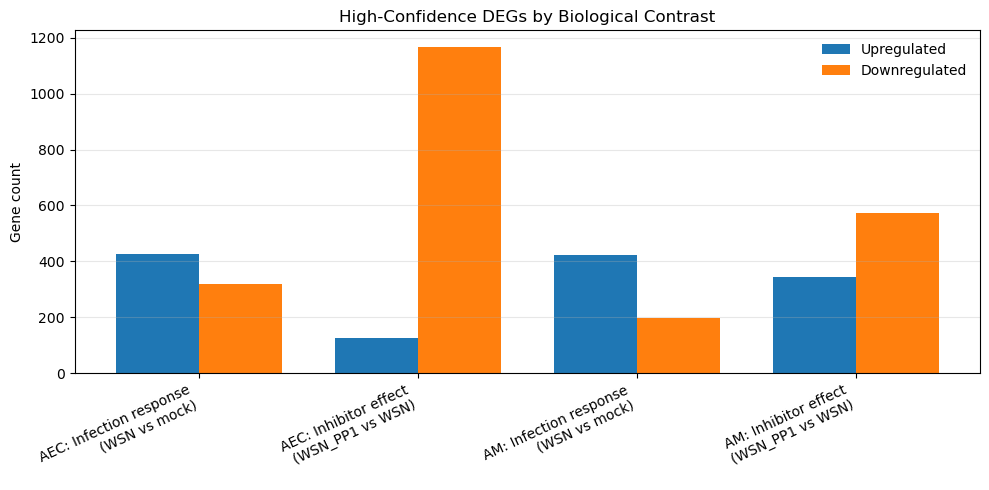

In [8]:
plot_df = summary_pivot.copy()

# Add concise biological context to x-axis labels
plot_df["comparison"] = (plot_df["cell_type"] + ": " +
                         plot_df["biological_question"] + "\n" +
                         "(" + plot_df["contrast"] + ")")

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width/2, plot_df["Upregulated"], width, label="Upregulated")
ax.bar(x + width/2, plot_df["Downregulated"], width, label="Downregulated")

ax.set_title("High-Confidence DEGs by Biological Contrast")
ax.set_ylabel("Gene count")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["comparison"], rotation=25, ha="right")

ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Top ranked genes

For each contrast, genes are ranked by:

1. adjusted p-value
2. absolute log2 fold change

This produces compact top-gene tables for downstream interpretation.


In [9]:
def get_top_genes(df, direction, n=10):
    """Return top genes in one regulation direction for each contrast."""
    out = []

    # Rank genes separately within each cell type and contrast
    for (cell_type, contrast), sub in df[df["regulation"] == direction].groupby(["cell_type", "contrast"]):
        ranked = (sub.assign(abs_log2fc=sub["log2FoldChange"].abs()).sort_values(["padj", "abs_log2fc"], ascending=[True, False]).head(n).copy())

        # Preserve whether the ranking came from the upregulated or downregulated set
        ranked["rank_direction"] = direction
        out.append(ranked)

    # Return an empty table if no genes match the requested direction
    if not out:
        return pd.DataFrame()

    return pd.concat(out, ignore_index=True)


# Get top upregulated and downregulated genes for each contrast
top_up = get_top_genes(deg, "Upregulated", n=10)
top_down = get_top_genes(deg, "Downregulated", n=10)
top_genes = pd.concat([top_up, top_down], ignore_index=True)

# Display compact fields for interpretation
display_cols = ["cell_type", "contrast", "rank_direction", "gene_label",
                "log2FoldChange", "padj", "biotype", "chromosome"]

top_genes[display_cols].head(40)

,cell_type,contrast,rank_direction,gene_label,log2FoldChange,padj,biotype,chromosome
0,AEC,WSN vs mock,Upregulated,Isg15,7.544477,0.000000e+00,protein_coding,4
1,AEC,WSN vs mock,Upregulated,Ifit3,7.372848,0.000000e+00,protein_coding,19
2,AEC,WSN vs mock,Upregulated,Gbp2,7.039520,0.000000e+00,protein_coding,3
3,AEC,WSN vs mock,Upregulated,Gm46878,6.883252,0.000000e+00,lncRNA,4
4,AEC,WSN vs mock,Upregulated,Irf7,6.389677,0.000000e+00,protein_coding,7
5,AEC,WSN vs mock,Upregulated,Art3,6.316955,0.000000e+00,protein_coding,5
6,AEC,WSN vs mock,Upregulated,Oasl2,5.881289,0.000000e+00,protein_coding,5
7,AEC,WSN vs mock,Upregulated,Cxcl10,5.822679,0.000000e+00,protein_coding,5
8,AEC,WSN vs mock,Upregulated,Ifit2,5.125197,0.000000e+00,protein_coding,19
9,AEC,WSN vs mock,Upregulated,Usp18,5.101842,0.000000e+00,protein_coding,6


In [10]:
# Save top gene table
top_genes[display_cols + ["gene_id", "description"]].to_csv(
    OUTPUT_DIR / "top_high_confidence_genes.csv",
    index=False
)
print("Saved:", OUTPUT_DIR / "top_high_confidence_genes.csv")

Saved: outputs\top_high_confidence_genes.csv


## Visualization 2: Top genes by fold change

This lollipop-style plot focuses only on high-confidence DEGs and highlights the most extreme positive and negative fold changes across all contrasts.


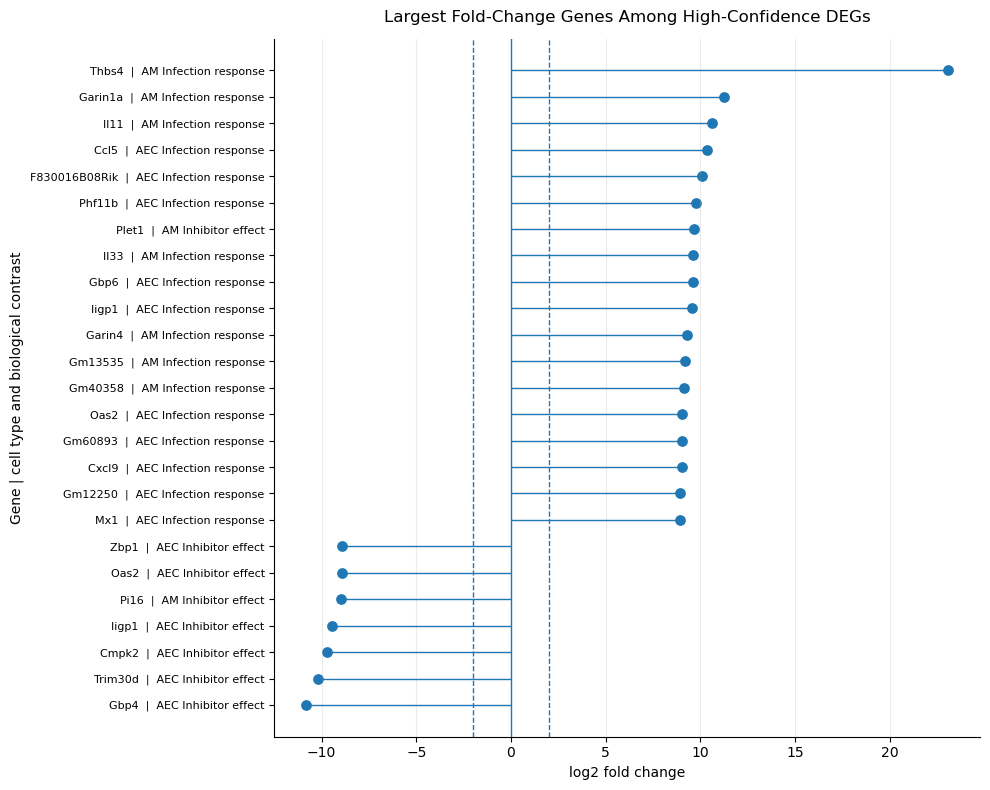

In [11]:
# Select strongest genes by absolute log2 fold change
top_lollipop = (high_conf.assign(abs_log2fc=high_conf["log2FoldChange"].abs()).sort_values("abs_log2fc", ascending=False).head(25).copy())

# Gene-first labels make the y-axis easier to scan
top_lollipop["label"] = (top_lollipop["gene_label"].astype(str) + "  |  " + top_lollipop["cell_type"] + " " + top_lollipop["biological_question"])

top_lollipop = top_lollipop.sort_values("log2FoldChange")

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(top_lollipop))

ax.hlines(y=y, xmin=0, xmax=top_lollipop["log2FoldChange"], linewidth=1)
ax.scatter(top_lollipop["log2FoldChange"], y, s=45)

ax.axvline(0, linewidth=1)
ax.axvline(LOG2FC_THRESHOLD, linestyle="--", linewidth=1)
ax.axvline(-LOG2FC_THRESHOLD, linestyle="--", linewidth=1)

ax.set_yticks(y)
ax.set_yticklabels(top_lollipop["label"], fontsize=8)

ax.set_xlabel("log2 fold change")
ax.set_ylabel("Gene | cell type and biological contrast")
ax.set_title("Largest Fold-Change Genes Among High-Confidence DEGs", pad=12)

ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Gene biotype summaries

Biotype annotations provide a quick overview of the major gene classes represented among high-confidence DEGs across cell types and contrasts.

This section summarizes DEG counts by annotated gene biotype.

In [12]:
# Biotype summary among high-confidence DEGs
biotype_summary = (high_conf.groupby(["cell_type", "contrast", "biotype"]).size().reset_index(name="gene_count")
                   .sort_values(["cell_type", "contrast", "gene_count"], ascending=[True, True, False]))

biotype_summary.head(20)

,cell_type,contrast,biotype,gene_count
6,AEC,WSN vs mock,protein_coding,582
3,AEC,WSN vs mock,lncRNA,142
2,AEC,WSN vs mock,TEC,9
5,AEC,WSN vs mock,processed_pseudogene,5
0,AEC,WSN vs mock,Mt_rRNA,2
4,AEC,WSN vs mock,miRNA,2
7,AEC,WSN vs mock,transcribed_unprocessed_pseudogene,2
1,AEC,WSN vs mock,Mt_tRNA,1
13,AEC,WSN_PP1 vs WSN,protein_coding,991
10,AEC,WSN_PP1 vs WSN,lncRNA,261


## Visualization 3: GC content distribution of high-confidence DEGs

GC-content distributions provide a simple annotation-level quality check for the DEG set. Extreme GC bias can sometimes reflect sequencing, alignment, or annotation artifacts.

The approximately normal distribution observed here suggests that high-confidence DEGs span a broad range of typical mammalian gene GC content rather than being dominated by extreme GC-content subsets.

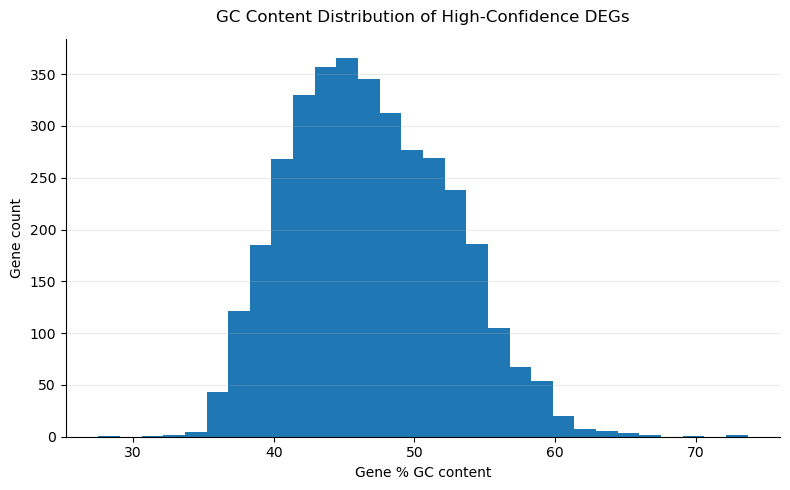

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(high_conf["gene_gc_content"].dropna(), bins=30)

ax.set_title("GC Content Distribution of High-Confidence DEGs", pad=12)
ax.set_xlabel("Gene % GC content")
ax.set_ylabel("Gene count")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Visualization 4: Annotation text mining

Bioinformatics workflows often require moving between many tools and annotation sources. This section uses lightweight text analysis to identify common words in gene descriptions among high-confidence DEGs.

This is not a replacement for formal gene ontology enrichment. It is a quick, transparent way to summarize recurring annotation terms directly from the available gene metadata.


In [14]:
# Stopwords for annotation text mining
stopwords = {

    # General English
    "the", "and", "or", "of", "to", "in", "a", "an",
    "for", "with", "by", "on", "at", "from", "as",
    "is", "are", "was", "were", "be", "this", "that",

    # Organism / species terms
    "mouse", "mus", "musculus",

    # Generic biological words
    "gene", "genes", "protein", "proteins",
    "factor", "activity", "related", "associated",
    "member", "group", "type", "complex",
    "chain", "subunit", "subfamily",
    "family", "superfamily", "homolog",

    # Annotation uncertainty / metadata
    "predicted", "uncharacterized",
    "putative", "hypothetical",
    "source", "coding",
    "acc", "mgi", "cdna",
    "riken", "ensembl",

    # Structural / domain-related terms
    "domain", "domains",
    "motif", "repeat", "rich",
    "containing", "coiled", "coil",
    "tripartite", "trim",
    "zinc", "finger",
    "transmembrane",

    # Sequence / genomic terminology
    "sequence", "strand",
    "open", "reading", "frame",
    "nucleotide", "acid",
    "region", "clade",

    # Generic molecular function terms
    "binding", "kinase",
    "receptor", "coupled",
    "transcription",

    # Naming / formatting artifacts
    "alpha", "beta", "gamma", "delta",
    "variant", "isoform",
    "symbol", "polypeptide",
    "opposite",

    # Generic size descriptors
    "small", "large",

    # Residual low-information terms
    "cold"}

def tokenize_annotation(text):
    """Tokenize annotation text into lowercase word tokens."""
    if pd.isna(text):
        return []

    text = str(text).lower()

    # Keep alphabetic words only, length >= 4
    tokens = re.findall(r"[a-z]{4,}", text)

    tokens = [token for token in tokens
              if token not in stopwords]

    return tokens

def make_bigrams(tokens):
    """Create adjacent two-word phrases from token list."""
    return [f"{tokens[i]} {tokens[i + 1]}"
            for i in range(len(tokens) - 1)]

# Use annotation fields only; exclude biotype because it adds metadata noise
high_conf["annotation_text"] = (high_conf["gene_label"].fillna("").astype(str) + " " +
                                high_conf["description"].fillna("").astype(str))

# Collect single-word terms and two-word phrases
all_terms = []
all_bigrams = []

for text in high_conf["annotation_text"]:
    tokens = tokenize_annotation(text)
    all_terms.extend(tokens)
    all_bigrams.extend(make_bigrams(tokens))

term_counts = pd.DataFrame(Counter(all_terms).most_common(30), columns=["term", "count"])

bigram_counts = pd.DataFrame(Counter(all_bigrams).most_common(30), columns=["phrase", "count"])

# Optional frequency filtering to reduce overly rare or overly broad terms
term_counts_filtered = term_counts[(term_counts["count"] >= 3) & (term_counts["count"] <= 50)].reset_index(drop=True)

bigram_counts_filtered = bigram_counts[(bigram_counts["count"] >= 2) & (bigram_counts["count"] <= 30)].reset_index(drop=True)

print("Top single annotation terms:")
display(term_counts_filtered.head(20))

print("Top annotation phrases:")
display(bigram_counts_filtered.head(20))

Top single annotation terms:


,term,count
0,cell,47
1,interacting,47
2,serine,46
3,specific,45
4,nuclear,44
5,peptidase,43
6,chemokine,42
7,gtpase,42
8,activated,41
9,growth,41


Top annotation phrases:


,phrase,count
0,interferon induced,27
1,interferon activated,22
2,peptidase inhibitor,22
3,tumor necrosis,21
4,cysteine peptidase,20
5,histocompatibility locus,19
6,serine cysteine,18
7,oligoadenylate synthetase,16
8,interferon inducible,16
9,tyrosine phosphatase,16


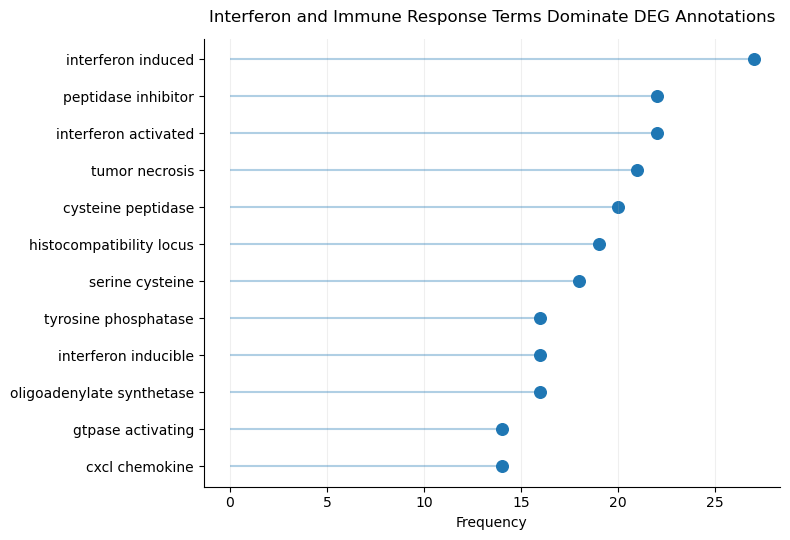

In [15]:
# Plot top annotation phrases as a dot/lollipop chart
top_phrases = (bigram_counts_filtered.head(12).sort_values("count"))

fig, ax = plt.subplots(figsize=(8, 5.5))

# Lollipop lines
ax.hlines(y=top_phrases["phrase"],
          xmin=0,
          xmax=top_phrases["count"],
          alpha=0.35)

# Endpoint dots
ax.scatter(top_phrases["count"],
           top_phrases["phrase"],
           s=70)

ax.set_title("Interferon and Immune Response Terms Dominate DEG Annotations", pad=12)
ax.set_xlabel("Frequency")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

Frequent annotation phrases were dominated by interferon-related and immune signaling terms, consistent with activation of innate antiviral response pathways during influenza infection. Additional enrichment of chemokine, ubiquitin ligase, and peptidase inhibitor annotations further supported a coordinated inflammatory host response.

## Annotation phrases by cell type and contrast

This section compares recurring annotation phrases across cell types and treatment contrasts. The goal is to identify whether high-confidence DEGs show different dominant biological themes across experimental groups.

In [16]:
## Annotation phrases by contrast

def top_phrases_for_group(df, cell_type, contrast, n=10):
    """Return the most common annotation phrases for one cell type and contrast."""
    sub = df[(df["cell_type"] == cell_type) & (df["contrast"] == contrast)]

    phrases = []

    for text in sub["annotation_text"]:
        tokens = tokenize_annotation(text)
        phrases.extend(make_bigrams(tokens))

    return pd.DataFrame(Counter(phrases).most_common(n), columns=["phrase", "count"])


group_phrase_tables = {}

for record in contrast_files:
    cell_type = record["cell_type"]
    contrast = record["contrast"]

    biological_question = contrast_label_map.get((cell_type, contrast), contrast)

    key = f"{cell_type}: {biological_question} ({contrast})"

    phrases = top_phrases_for_group(high_conf,
                                    cell_type,
                                    contrast,
                                    n=10)

    group_phrase_tables[key] = phrases

    print("\n" + key)
    display(phrases)


AEC: Infection response (WSN vs mock)


,phrase,count
0,chemokine ligand,13
1,interferon induced,11
2,interferon activated,11
3,oligoadenylate synthetase,7
4,interferon inducible,7
5,histocompatibility locus,7
6,solute carrier,7
7,tumor necrosis,6
8,slfn schlafen,6
9,adhesion molecule,5



AEC: Inhibitor effect (WSN_PP1 vs WSN)


,phrase,count
0,interferon induced,11
1,interferon activated,11
2,chemokine ligand,10
3,tyrosine phosphatase,9
4,solute carrier,9
5,ubiquitin ligase,9
6,oligoadenylate synthetase,8
7,tumor necrosis,8
8,histocompatibility locus,7
9,cysteine peptidase,6



AM: Infection response (WSN vs mock)


,phrase,count
0,chemokine ligand,7
1,peptidase inhibitor,6
2,solute carrier,6
3,cxcl chemokine,5
4,high mobility,4
5,serine cysteine,4
6,cysteine peptidase,4
7,tyrosine phosphatase,4
8,toll like,4
9,ifna interferon,4



AM: Inhibitor effect (WSN_PP1 vs WSN)


,phrase,count
0,solute carrier,9
1,clec lectin,7
2,peptidase inhibitor,7
3,lysine specific,7
4,pleckstrin homology,6
5,chemokine ligand,5
6,heat shock,5
7,serine cysteine,5
8,cysteine peptidase,5
9,specific methyltransferase,5


Annotation phrase patterns differed across contrasts and broadly matched the biological themes identified through GO enrichment analysis. AEC contrasts were dominated by interferon and antiviral response phrases, while AM contrasts showed stronger inflammatory, cytokine, and immune-remodeling signatures. The inhibitor contrasts retained many infection-associated immune terms but also showed evidence of transcriptional reprogramming toward altered signaling and cellular-state pathways.

## Optional: export a clean reporting table

The table below can be used in a report, presentation, or follow-up analysis. It includes only the highest-confidence DEGs and compact annotation fields.


In [17]:
## Export clean DEG reporting table

# Create a compact export table for reporting or follow-up analysis
report_table = high_conf[["cell_type", "biological_question", "contrast",
                          "gene_id", "gene_label",
                          "regulation", "log2FoldChange", "padj",
                          "biotype", "chromosome", "description"]].copy()

# Clean annotation descriptions for readability
report_table["description"] = (report_table["description"].fillna("").astype(str)
                               .str.replace(r"\[.*?\]", "", regex=True)   # remove [Source:...]
                               .str.replace(r"RIKEN cDNA", "", regex=False)
                               .str.replace(r"predicted gene,", "", regex=False)
                               .str.replace(r"\s+", " ", regex=True).str.strip())

# Add absolute effect size for easier ranking
report_table["abs_log2FoldChange"] = report_table["log2FoldChange"].abs()

# Format numeric columns for readability
report_table["log2FoldChange"] = report_table["log2FoldChange"].round(3)
report_table["abs_log2FoldChange"] = report_table["abs_log2FoldChange"].round(3)
report_table["padj"] = report_table["padj"].apply(lambda x: f"{x:.2e}")

# Reorder columns for reporting
report_table = report_table[["cell_type",
                             "biological_question",
                             "contrast",
                             "gene_label",
                             "gene_id",
                             "regulation",
                             "log2FoldChange",
                             "abs_log2FoldChange",
                             "padj",
                             "biotype",
                             "chromosome",
                             "description"]]

# Sort by group, statistical significance, then effect size
report_table = report_table.sort_values(["cell_type", "biological_question", "contrast", "padj", "abs_log2FoldChange"],
                                        ascending=[True, True, True, True, False])

# Save clean report table
report_path = OUTPUT_DIR / "high_confidence_deg_report_table.csv"
report_table.to_csv(report_path, index=False)

print(f"Report rows: {len(report_table):,}")
print("Saved:", report_path)

report_table.head(20)

Report rows: 3,575
Saved: outputs\high_confidence_deg_report_table.csv


,cell_type,biological_question,contrast,gene_label,gene_id,regulation,log2FoldChange,abs_log2FoldChange,padj,biotype,chromosome,description
12,AEC,Infection response,WSN vs mock,Isg15,ENSMUSG00000035692,Upregulated,7.544,7.544,0.00e+00,protein_coding,4,ISG15 ubiquitin-like modifier
23,AEC,Infection response,WSN vs mock,Ifit3,ENSMUSG00000074896,Upregulated,7.373,7.373,0.00e+00,protein_coding,19,interferon-induced protein with tetratricopeptide repeats 3
4,AEC,Infection response,WSN vs mock,Gbp2,ENSMUSG00000028270,Upregulated,7.040,7.040,0.00e+00,protein_coding,3,guanylate binding protein 2
24,AEC,Infection response,WSN vs mock,Gm46878,ENSMUSG00000120951,Upregulated,6.883,6.883,0.00e+00,lncRNA,4,46878
2,AEC,Infection response,WSN vs mock,Irf7,ENSMUSG00000025498,Upregulated,6.390,6.390,0.00e+00,protein_coding,7,interferon regulatory factor 7
8,AEC,Infection response,WSN vs mock,Art3,ENSMUSG00000034842,Upregulated,6.317,6.317,0.00e+00,protein_coding,5,ADP-ribosyltransferase 3
5,AEC,Infection response,WSN vs mock,Oasl2,ENSMUSG00000029561,Upregulated,5.881,5.881,0.00e+00,protein_coding,5,2'-5' oligoadenylate synthetase-like 2
9,AEC,Infection response,WSN vs mock,Cxcl10,ENSMUSG00000034855,Upregulated,5.823,5.823,0.00e+00,protein_coding,5,C-X-C motif chemokine ligand 10
14,AEC,Infection response,WSN vs mock,Ifit2,ENSMUSG00000045932,Upregulated,5.125,5.125,0.00e+00,protein_coding,19,interferon-induced protein with tetratricopeptide repeats 2
6,AEC,Infection response,WSN vs mock,Usp18,ENSMUSG00000030107,Upregulated,5.102,5.102,0.00e+00,protein_coding,6,ubiquitin specific peptidase 18


## Interpretation guide

The generated tables and visualizations summarize transcriptional response patterns across the four DESeq2 contrasts.

Key interpretation areas:

1. **Magnitude and direction of response**  
   DEG counts and regulation patterns indicate the strength and direction of transcriptional change within each contrast.

2. **Strongest DEG candidates**  
   Genes with low adjusted p-values and large absolute log2 fold changes represent the strongest candidates for biological interpretation.

3. **Annotation phrase patterns**  
   Recurring annotation phrases highlighted interferon signaling, antiviral response, cytokine activity, and immune regulation themes that were broadly consistent with GO enrichment results. These summaries are exploratory and should not be interpreted as formal pathway enrichment analysis.

4. **Cell-type-specific response**  
   Comparing AEC and AM contrasts helps identify differences in epithelial versus macrophage response to influenza infection and TrkA inhibition.

## Limitations

This notebook depends on the quality of the upstream DESeq2 analysis and annotation sources.

Key limitations:

- The notebook does not rerun DESeq2 statistical modeling.
- Annotation phrase analysis is descriptive, not formal GO enrichment.
- Strict DEG thresholds may exclude smaller but biologically relevant effects.
- Annotation completeness can affect text-mining results.
- Small sample sizes limit biological generalizability.
- Transcriptomic findings require experimental validation.

Despite these limitations, the workflow provides a reproducible Python-based reporting layer for consolidating, visualizing, and interpreting DESeq2 differential expression results.

## Conclusion

This project demonstrates how Python can extend an R-based differential expression workflow without duplicating the original statistical analysis.

The notebook imports and standardizes annotated DESeq2 outputs, applies consistent high-confidence DEG filtering, summarizes transcriptional response patterns, generates visualization and reporting tables, and performs lightweight annotation phrase analysis.

Across contrasts, high-confidence DEG patterns were dominated by interferon signaling, antiviral response, cytokine activity, and immune regulation terms, consistent with expected host response pathways during influenza infection.

Overall, the workflow demonstrates a practical bioinformatics data-integration task: consolidating outputs from multiple analytical tools into a single interpretable and reproducible analysis notebook.